# Przygotowanie

Przygotowanie Przed rozpoczęciem pracy z notatnikiem proszę zmienić jego nazwę dodając na początku numer albumu, imię i nazwisko. {nr_albumu}_{imię}_{nazwisko}_{nazwa}

Po wykonaniu wszystkich zadań proszę przesłać wypełniony notatnik przez platformę TEAMS.

# Drzewa decyzyjne

Podobnie jak w przypadku maszyny wektorów nosnych (SVC), drzewa decyzyjne sa wszechstronnym algorytmem uczenia maszynowego. Mogą słuzyc do rozwiazywania problemów zarówno klasyfikacji, jak i regresji. W przeciwieństwie do modelu SVC drzewa decyzyjne nie wymagają restrykcyjnego przygotowania danych (np. skalowania cech). Drzewa decyzyjne składaja sie z korzenia oraz gałezi prowadzacych do kolejnych wierzchołków. W wezłach - wierzchołkach z których wychodzi co najmniej jedna krawedź, sprawdzany jest pewien warunek. Na jego podstawie, wybierana jest gałaz prowadząca do kolejnego wierzchołka. Dana obserwacja zostaje zaklasyfikowana do konkretnej klasy po przejściu od korzenia do liscia i przypisaniu do tej obserwacji klasy, z danego liscia (nie wychodza z niego wezły potomne).

Za pomocą drzew decyzyjnych otrzymać możemy potężne modele zdolne do nauki złożonych zbiorów danych.

###  Las losowy

Klasyfikator lasu losowego jest klasyfikatorem zespołowym złozonym z drzew decyzyjnych. Klasyfikator ten wprowadza dodatkową losowość do wzrostu drzew. Nie wyszukuje on najlepszej cechy podczas podziału na wezły, ale szuka najlepszej cechy wsród losowego podziału cech. Powoduje to wieksze zróznicowanie powstałych w klasyfikatorze drzew. Losowe lasy są bardziej odporne na nadmierne dopasowanie się do zbioru treningowego, jakie spotykane jest podczas użycia drzew decyzyjnych.

In [91]:
import pandas as pd
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
#data = pd.read_csv()
#colA = data['colA'].values.T
X = iris.data[:, [2, 3]]
y = iris.target

print('Class labels:', np.unique(y))

Class labels: [0 1 2]


In [92]:
unique, counts = np.unique(y, return_counts=True)
dict(zip(unique, counts))

{np.int64(0): np.int64(50),
 np.int64(1): np.int64(50),
 np.int64(2): np.int64(50)}

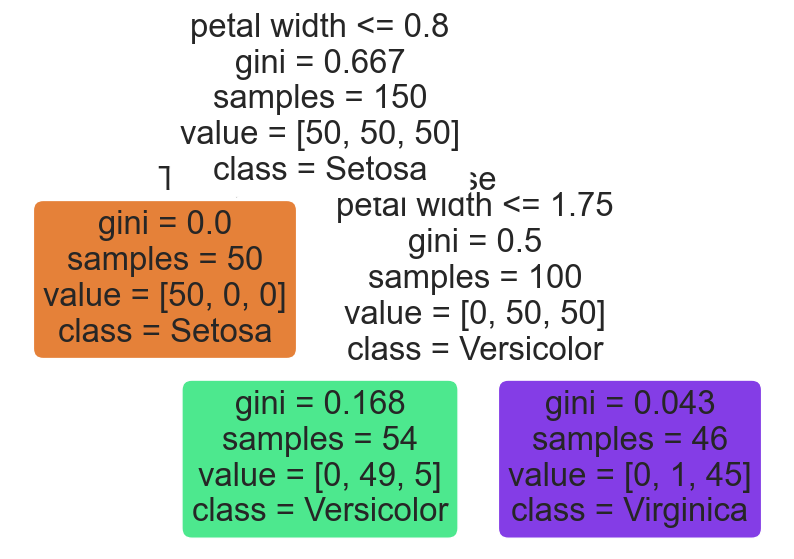

In [93]:
import matplotlib.pyplot as plt
from pydotplus import graph_from_dot_data
from sklearn.tree import DecisionTreeClassifier, export_graphviz

from sklearn.tree import plot_tree

tree = DecisionTreeClassifier(criterion='gini', max_depth=2, random_state=1)
tree.fit(X, y)

plt.figure(figsize=(10, 7))

plot_tree(tree, 
          filled=True, 
          rounded=True,
          class_names=['Setosa', 
                       'Versicolor',
                       'Virginica'],
          feature_names=['petal length', 
                         'petal width']) 

plt.show()

### Jak podejmowane są decyzje w drzewie?

Klasyfikacja próbki zaczyna się zawsze od korzenia (węzeł na samej górze grafu). W węźle zadawane jest pytanie (w przykładnie powyżej czy długość płatka jest mniejsza od 0.8). Jeśli prawda przechodzimy do węzła potomnego lewego, w przeciwnym razie do prawego. Przechodząc do węzła lewego dochodzimy do **liścia** (leaf node, nie posiada węzłów potomnych) - w taki wypadku żadne pytanie nie jest zadawane, przydzielana jest już tylko klasa do danej obserwacji. 

W przypadku, gdy skierujemy się ku węzłowi prawemu (nie jest już liściem) zadajemy kolejne pytanie, aż dojdziemy do liścia.

Znaczenie atrybutów:

- *samples* - oznacza ilość wyznaczonych próbek dla danego węzła (zgadza się to w przedstawionym przypadku z ilością próbek dla danych klas)
- *value* - określa ilość przykładów uczących z każdej klasy jakie przynależą do danego węzła.
- *gini* - miara zanieczyszczenia węzła (0 oznacza, że wszystkie próbki w węźle należą do jednej klasy - idealna klasyfikacja)

Wskaźnik Gingiego:
    \begin{equation*}
 G_{i} = 1 - \sum_{k=1}^{n} p_{i, k}^{2}
\end{equation*}
gdzie $p_{i,k}$ oznacza współczynie występowania klas k, wśród próbek uczących w węźle i.

Jako wskaźnik zanieczyszczenia (parametr *entropy*), użyta może zostać również miara entropii. Wynosi ona 0, w przypadku, gdy wszystkie informacje są takie same - wszystkie próbiki w węźle należą do jednej klasy.

Entropia:
    
\begin{equation*}
    H_{i} = - \sum_{k=1\\ p_{i,k} \neq 0}^{n} p_{i, k} log(p_{i,k})
\end{equation*}


Różnice pomędzy tymi dwoma miarami są zazwyczaj bardzo znikome i nie wypływają znacząco na skuteczność działania klasyfikatora. Dla zainteresowanych szczegółami zapraszam do lektury: https://sebastianraschka.com/faq/docs/decision-tree-binary.html, https://towardsdatascience.com/the-simple-math-behind-3-decision-tree-splitting-criterions-85d4de2a75fe

W jakim momencie przestać budować drzewo decyzyje?

Problemy rozważane w uczeniu maszynowym mają zazwyczaj sporą liczbę cech, która może powodować wysoko rosnące skomplikowanie drzewa (jego wielkość, sporą ilość węzłów oraz podziałów w węzłach). Tak utworzone drzewa mogą powodować nadmierne dopasowanie do danych treningowych.

Algorytm drzewa decyzyjnego posiada parametry, które ustalane są podczas uczenia. Jak wspomniano, może powodować to przetrenowanie klasyfikatora (nadmierne dopasowanie do danych uczących). Aby tego uniknąć, dobrym rozwiązaniem okazuje się ograniczenie swobody działania klasyfikatora. Podobnie jak w przypadku klasyfikatora SVC, również dla drzewa decyzyjnego zdefinowane zostały parametry regularyzacyjne:

- *max_depth* - maksymalna wysokość drzewa
- *min_samples_split* - minimalna liczba próbek, jakie będą w węźle (przed podziałem)
- *min_samples_leaf* - minimalna liczba próbek, jakie będą w liściu
- *max_leaf_nodes* - maksymalna ilość liści
- *max_features* - maksymalna liczba cech używana do dzielenia węzła.

Modyfikacja tych parametrów powoduje regularyzację drzewa i zmniejsza ryzyko przetrenowania.

## Zadania

### Zadanie 1

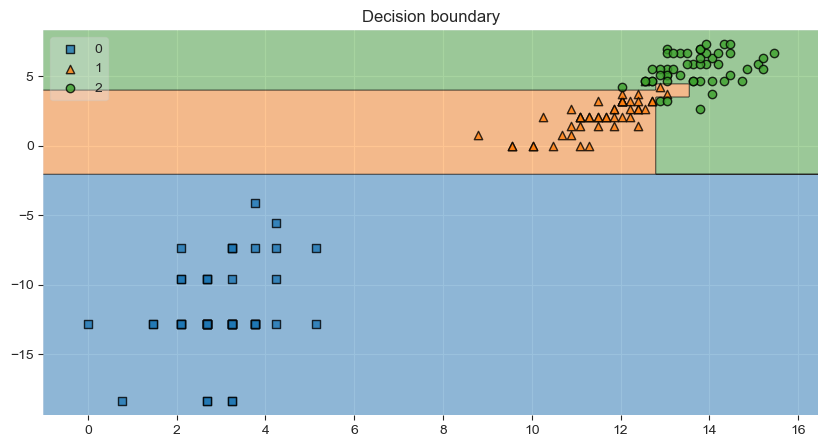

In [94]:
from mlxtend.plotting import plot_decision_regions

tree = DecisionTreeClassifier(max_depth=10, criterion="entropy", random_state=1)
tree.fit(np.log(X ** 8), y)
fig = plt.figure(figsize=(10,5))
labels = ['Decision Tree']
fig = plot_decision_regions(X=np.log(X ** 8), y=y, clf=tree, legend=2)
plt.title("Decision boundary")
plt.show()

Jakie wnioski możne sformuować na bazie granic decyzyjnych przedstawionych powyżej? W momencie pojawianie się dodatkowej próbki klasy *zielonej* (2), zostanie ona dobrze sklasyfikowana? Czy klasyfikator posiada dobre właściwości generalizujące?

Klasa zielona (2) oraz klasa pomarańczowa (1) maja dość skomplikowana schodkowa granicę. Jeśli nowy punkt pojawi się w chmurze zielony puntktów to model sobie poradzi, natomiast gdy blisko granicy z pomarańczowa to pojawi sie problem z predykcja. Klasyfikator wyglada na przeczony, który jest zbyt dopasowany do zbiour treningowego i ma słabe właściwości generalizujace.

### Zadanie 2

Proszę o wczytanie, opisanie zbioru danych: https://www.kaggle.com/datasets/mathchi/diabetes-data-set. Proszę o usunięcie danych None. Zbiór danych powinien być użyty do dalszych oblicze

In [95]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [96]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


W zbiorze nie ma brakuJcych wartosci

### Zadanie 3

Proszę wytrenować zbiór z użyciem algorytmu drzewa decyzyjnego. Proszę pamiętać o odpowiednim podziale na zbiór uczący i treningowy. Klasyfikator powinien być trenowany na zbiorze treningowym, a wynik jego skuteczności po trenowaniu obliczany w oparciu o zbiór testowy.

Proszę przygotować wyniki, trenując algorytm z użyciem różnych parametrów - należy przygotować wykresy (oś pionowa określa skuteczność, pozioma wartość parametru) pokazujące jak zmienia się skuteczność działania w zależności od zastosowanych wartości parametrów. Proszę o przygotowanie odpowiedniego porównania (tabela), co można zaobserwować?

In [98]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
 

X = df.drop('Outcome', axis=1) 
y = df['Outcome']

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [100]:
def test_param(param_name, values):
    accuracies = []
    for val in values:
        kwargs = {param_name: val, 'random_state': 42}
        clf = DecisionTreeClassifier(**kwargs)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))
    return accuracies


In [101]:
max_depth_values = range(1, 21)
min_samples_split_values = range(2, 21)
min_samples_leaf_values = range(1, 21)
max_leaf_nodes_values = range(2, 21)
max_features_values = list(range(1, X.shape[1]+1))

In [102]:
accuracy_max_depth = test_param('max_depth', max_depth_values)
accuracy_min_samples_split = test_param('min_samples_split', min_samples_split_values)
accuracy_min_samples_leaf = test_param('min_samples_leaf', min_samples_leaf_values)
accuracy_max_leaf_nodes = test_param('max_leaf_nodes', max_leaf_nodes_values)
accuracy_max_features = test_param('max_features', max_features_values)

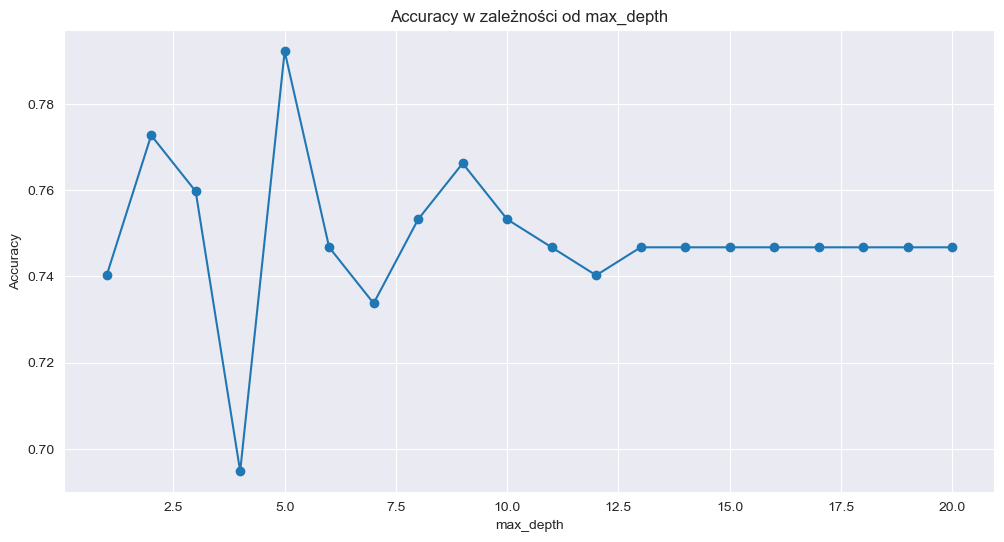

In [103]:
plt.figure(figsize=(12, 6))
plt.plot(max_depth_values, accuracy_max_depth, marker='o')
plt.title('Accuracy w zależności od max_depth')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.grid(True)

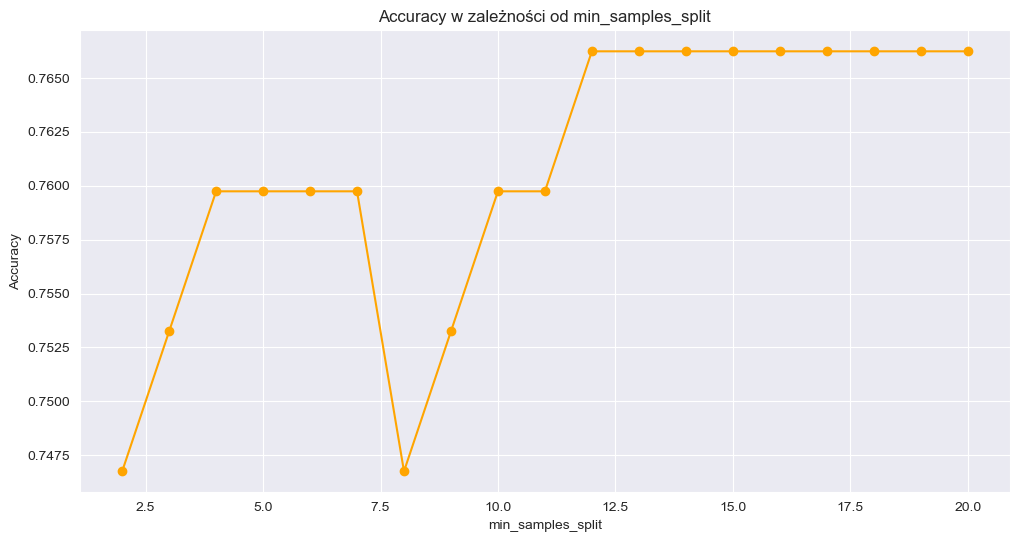

In [104]:
plt.figure(figsize=(12, 6))
plt.plot(min_samples_split_values, accuracy_min_samples_split, marker='o', color='orange')
plt.title('Accuracy w zależności od min_samples_split')
plt.xlabel('min_samples_split')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

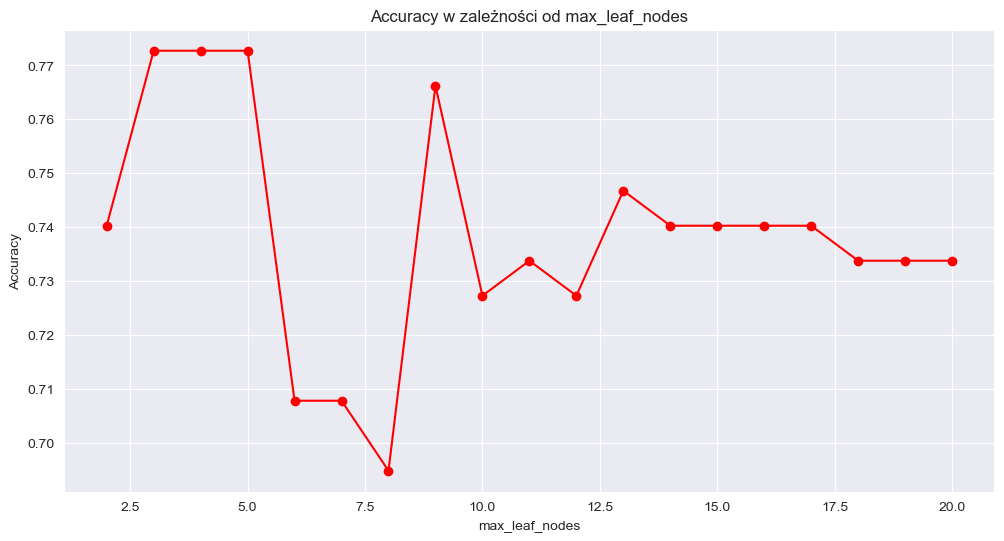

In [105]:
plt.figure(figsize=(12, 6))
plt.plot(max_leaf_nodes_values, accuracy_max_leaf_nodes, marker='o', color='red')
plt.title('Accuracy w zależności od max_leaf_nodes')
plt.xlabel('max_leaf_nodes')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

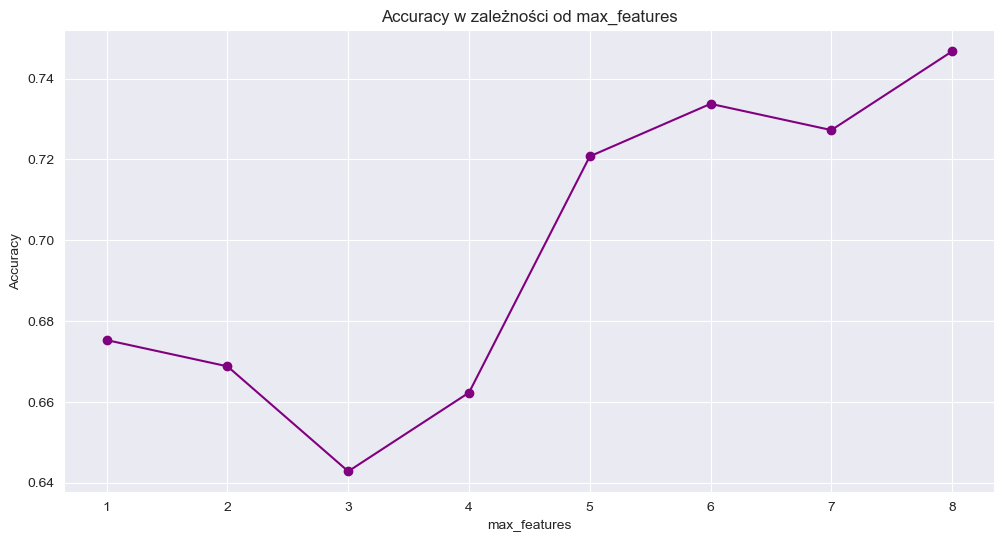

In [106]:
plt.figure(figsize=(12, 6))
plt.plot(max_features_values, accuracy_max_features, marker='o', color='purple')
plt.title('Accuracy w zależności od max_features')
plt.xlabel('max_features')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [107]:
comparison_df = pd.DataFrame({
    'max_depth': max_depth_values,
    'accuracy_max_depth': accuracy_max_depth,
    'min_samples_split': list(min_samples_split_values) + [None]*(len(max_depth_values)-len(min_samples_split_values)),
    'accuracy_min_samples_split': accuracy_min_samples_split + [None]*(len(max_depth_values)-len(min_samples_split_values)),
    'min_samples_leaf': list(min_samples_leaf_values) + [None]*(len(max_depth_values)-len(min_samples_leaf_values)),
    'accuracy_min_samples_leaf': accuracy_min_samples_leaf + [None]*(len(max_depth_values)-len(min_samples_leaf_values)),
    'max_leaf_nodes': list(max_leaf_nodes_values) + [None]*(len(max_depth_values)-len(max_leaf_nodes_values)),
    'accuracy_max_leaf_nodes': accuracy_max_leaf_nodes + [None]*(len(max_depth_values)-len(max_leaf_nodes_values)),
    'max_features': list(max_features_values) + [None]*(len(max_depth_values)-len(max_features_values)),
    'accuracy_max_features': accuracy_max_features + [None]*(len(max_depth_values)-len(max_features_values)),
})


In [108]:
comparison_df

,max_depth,accuracy_max_depth,min_samples_split,accuracy_min_samples_split,min_samples_leaf,accuracy_min_samples_leaf,max_leaf_nodes,accuracy_max_leaf_nodes,max_features,accuracy_max_features
0,1,0.740260,2.0,0.746753,1,0.746753,2.0,0.740260,1.0,0.675325
1,2,0.772727,3.0,0.753247,2,0.746753,3.0,0.772727,2.0,0.668831
2,3,0.759740,4.0,0.759740,3,0.727273,4.0,0.772727,3.0,0.642857
3,4,0.694805,5.0,0.759740,4,0.720779,5.0,0.772727,4.0,0.662338
4,5,0.792208,6.0,0.759740,5,0.746753,6.0,0.707792,5.0,0.720779
5,6,0.746753,7.0,0.759740,6,0.733766,7.0,0.707792,6.0,0.733766
6,7,0.733766,8.0,0.746753,7,0.766234,8.0,0.694805,7.0,0.727273
7,8,0.753247,9.0,0.753247,8,0.766234,9.0,0.766234,8.0,0.746753
8,9,0.766234,10.0,0.759740,9,0.733766,10.0,0.727273,NaN,NaN
9,10,0.753247,11.0,0.759740,10,0.740260,11.0,0.733766,NaN,NaN


max_depth: Najlepszy wynik daje głębokość 5, a wyższe wartości prowadzą do spadku skuteczności przez przeuczenie.

min_samples_split: Zwiększenie parametru powyżej 12 poprawia wynik, eliminując zbyt szczegółowe i nieistotne podziały.

min_samples_leaf: Ustawienie wartości na 7-8 stabilizuje model i polepsza jego zdolność do generalizacji.

max_leaf_nodes: Ograniczenie drzewa do zaledwie 3-4 liści daje bardzo wysoką skuteczność, co świadczy o prostocie problemu.

max_features: Model działa najlepiej, gdy przy podziałach uwzględnia większość dostępnych cech (wartość 8).

### Zadanie 4

Drzewa decyzyjne mogą również szacować przewdopodobieństwo przynależności danej próbki do określonej klasy. Proszę przeprowadzić odpowiednie trenowanie klasyfikatora i określić jak zmienia się prawdopodobieństwo przynależności różnych próbek. Wystarczy odnaleźć odpowienią właściwość klasyfikatora i pokazać jakie jest zwracane prawdopodobieństwo dla kilku przykładów.

In [109]:
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

all_probs = clf.predict_proba(X_test)
all_preds = clf.predict(X_test)

print(f"{'Próbka':<8} | {'Klasa 0':<10} | {'Klasa 1':<10} | {'Decyzja modelu'}")
print("-" * 55)

for i in range(20):

    p_class_0 = all_probs[i][0]
    p_class_1 = all_probs[i][1]
    
    prediction = all_preds[i]
    
    print(f"{i:<8} | {p_class_0:.4f}     | {p_class_1:.4f}     | {prediction}")

Próbka   | Klasa 0    | Klasa 1    | Decyzja modelu
-------------------------------------------------------
0        | 0.5753     | 0.4247     | 0
1        | 0.9180     | 0.0820     | 0
2        | 1.0000     | 0.0000     | 0
3        | 1.0000     | 0.0000     | 0
4        | 1.0000     | 0.0000     | 0
5        | 0.5753     | 0.4247     | 0
6        | 1.0000     | 0.0000     | 0
7        | 0.2581     | 0.7419     | 1
8        | 0.3704     | 0.6296     | 1
9        | 0.3704     | 0.6296     | 1
10       | 0.5753     | 0.4247     | 0
11       | 0.2143     | 0.7857     | 1
12       | 0.0000     | 1.0000     | 1
13       | 0.2581     | 0.7419     | 1
14       | 1.0000     | 0.0000     | 0
15       | 0.7353     | 0.2647     | 0
16       | 0.9180     | 0.0820     | 0
17       | 1.0000     | 0.0000     | 0
18       | 0.5833     | 0.4167     | 0
19       | 0.6250     | 0.3750     | 0


### Zadanie 5

Proszę wyrysować granice decyzyjne dla klasyfikatora drzewa decyzyjnego utworzonego we wcześniejszym zadaniu. Jakie można sformuować wnioski?

<Axes: >

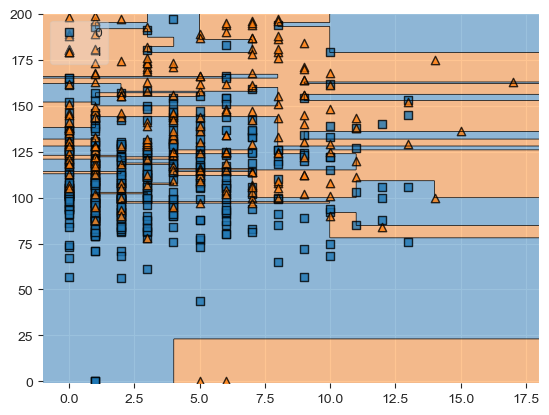

In [110]:
X_2d = X_train.iloc[:, :2].values 
y_train_2d = y_train.values

tree.fit(X_2d, y_train_2d)
plot_decision_regions(X=X_2d, y=y_train_2d, clf=tree, legend=2)

Klasyfikator z poprzedniego zadania był tworzony z użyciem wszystkich zmienny, więc zwizualizowanie jego granic jest niemożliwe. Aby to osiagnac stworzono nowy klasyfikator z 2 cechami. 

Przedstawione granice decyzyjne obrazują zjawisko przeuczenia , gdzie model zamiast wykryć ogólne zależności, zapamiętał szum i układ poszczególnych punktów treningowych. W konsekwencji klasyfikator ten posiada bardzo słabe właściwości generalizujące.

### Zadanie 6

Proszę dokonać optymalizacji paramertrów (min. 3) modelu w oparciu o metodę przeszukiwania siatki: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#sklearn.model_selection.GridSearchCV

In [111]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'max_depth': [3, 5, 7, 10, 15],         
    'min_samples_split': [2, 5, 10, 15, 20, 30],       
    'min_samples_leaf': [1, 2, 5, 10, 15]          
}


tree = DecisionTreeClassifier(random_state=42)


grid_search = GridSearchCV(estimator=tree, 
                           param_grid=param_grid, 
                           cv=6, 
                           scoring='accuracy')


grid_search.fit(X_train, y_train)


print('Najlepsze parametry:', grid_search.best_params_)
print('Najlepsza skuteczność (cross-validation):', grid_search.best_score_)


best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'\nSkuteczność najlepszego modelu na zbiorze testowym: {acc:.4f}')

Najlepsze parametry: {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Najlepsza skuteczność (cross-validation): 0.7589314042769212

Skuteczność najlepszego modelu na zbiorze testowym: 0.7792


Model osiaga zblizona skutecznosc na zbiorze walidacyjnym oraz testowym co sugeruje ze radzi sobie z generalizacja problemu.

Text(0.5, 1.0, 'Skuteczność modelu (Accuracy)\n(przy min_samples_split=2)')

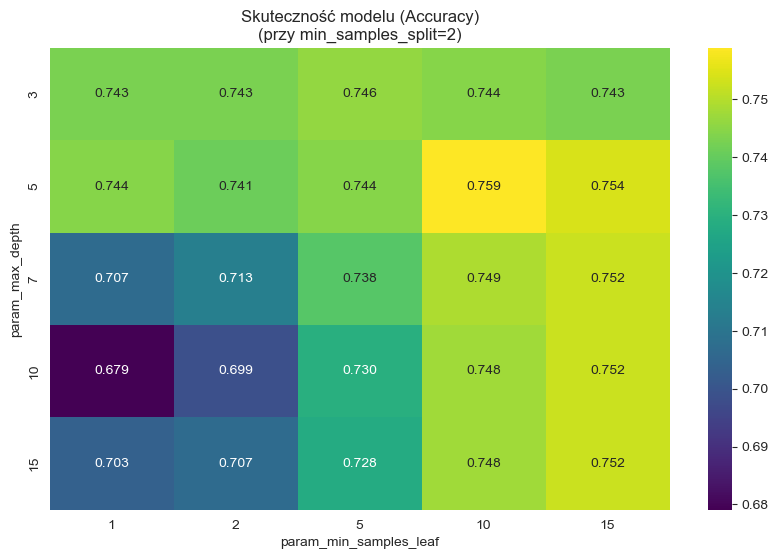

In [112]:
import seaborn as sns 
results_df = pd.DataFrame(grid_search.cv_results_)

df_subset = results_df[['param_max_depth', 'param_min_samples_leaf', 'param_min_samples_split', 'mean_test_score']]

# zeby zwizualizowac wybrano jeden parametr jako stala
df_heatmap = df_subset[df_subset['param_min_samples_split'] == 2]


pivot_table = df_heatmap.pivot(index='param_max_depth', 
                               columns='param_min_samples_leaf', 
                               values='mean_test_score')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt=".3f")
plt.title('Skuteczność modelu (Accuracy)\n(przy min_samples_split=2)')


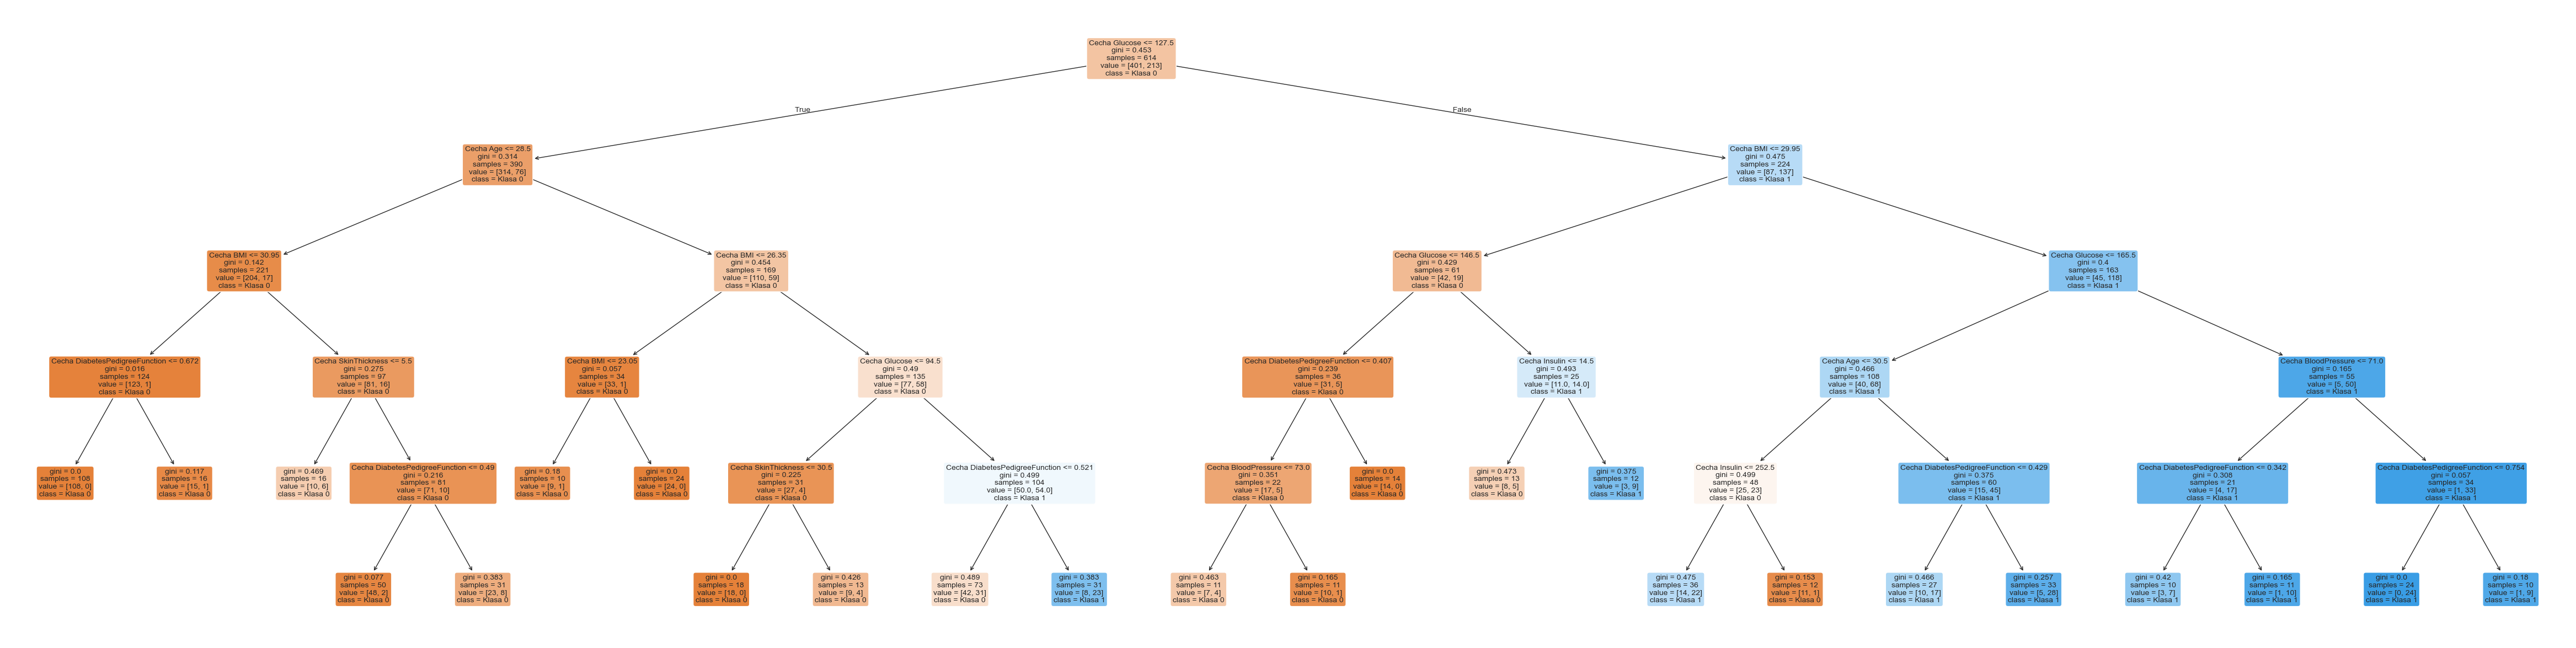

In [113]:
plt.figure(figsize=(60, 15))
plot_tree(grid_search.best_estimator_, 
          filled=True, 
          feature_names=[f'Cecha {col}' for col in X_train.columns],
          class_names=['Klasa 0', 'Klasa 1'],
          rounded=True,
          fontsize=10)
plt.show()